# Credit Card Fraud Detection Using Machine Learning

**MLP 3: Final Report — Random Forest Pipeline**  
**Project Title:** Credit Card Fraud Detection  
**Team Members:** Hongru He, Ramya Ramesh  
**Repository:** [GitHub link to main repo] — Add *DialaE* as collaborator for grading.  
**Date:** March 2026

---

## 1. Problem Statement (Content: Problem Statement)

### 1.1 Goal and Motivation

This project builds a machine learning model to **detect fraudulent credit card transactions**. The task is **binary classification**: given a transaction, predict whether it is **fraudulent (Class=1)** or **legitimate (Class=0)**. Fraud is extremely rare (~0.17% of transactions), making this a challenging **imbalanced** problem.

**Why it matters (non-technical):** Fraud causes direct financial loss and erodes customer trust. Catching more fraud protects the business; too many false alarms create friction for honest customers. Our goal is to **miss as few real frauds as possible** while keeping false alarms manageable.

### 1.2 Task and Success Criteria

- **Task:** Given transaction features (anonymized PCA components V1–V28 and transaction amount), predict Class (0/1).
- **Objective:** Minimize **false negatives** (missed fraud) while controlling **false positives** (incorrect flags).
- **Deployment context:** The model is intended for a **real-time scoring system**: high-confidence fraud → automatic block or alert; moderate confidence → human review queue.

**Measurable success:** We do **not** use accuracy (misleading with imbalance). We use **precision**, **recall**, **F1**, and **PR-AUC**, with emphasis on **recall for the fraud class**. We define success as:
- **Recall ≥ 0.95** (catch at least 95% of frauds).
- Then **maximize precision** at that recall (fewer false alarms).

**Why we prioritize recall:** In this context, missing fraud is costlier than extra false alarms. We therefore choose the decision threshold so that Recall(t) ≥ 0.95 and we maximize Precision(t) subject to that constraint.

## 2. Data Acquisition, Exploration, and Cleaning (Content: Data)

We load the **Credit Card Fraud Detection** dataset (Kaggle / ULB ML Group), explore it, and clean/transform it for modeling.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

# Load data
data = pd.read_csv("creditcard.csv")
data = data.dropna().reset_index(drop=True)
data["Class"] = data["Class"].astype(int)

print("Dataset shape:", data.shape)
print("\nClass distribution:")
print(data["Class"].value_counts(normalize=True).to_string())
print(f"\nFraud share: {data['Class'].mean()*100:.2f}%")

Dataset shape: (284807, 31)

Class distribution:
Class
0    0.998273
1    0.001727

Fraud share: 0.17%


### 2.1 Exploratory Data Analysis (EDA)

- **Target:** `Class` (0 = legitimate, 1 = fraud). **Severe class imbalance** (~0.17% fraud).
- **Features:** V1–V28 are PCA-transformed (anonymized); `Time` = seconds since first transaction; `Amount` = transaction amount. All numeric.
- **Cleaning:** No missing values after `dropna()`. We scale **Amount** and drop **Time** (see below).

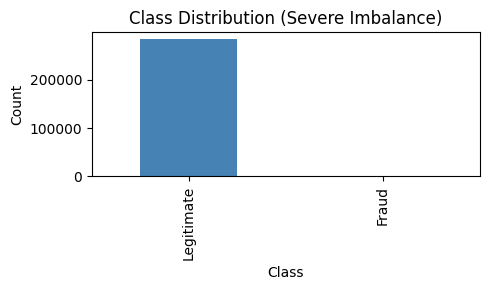

In [2]:
# Class distribution figure (for report)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
data["Class"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_ylabel("Count")
ax.set_title("Class Distribution (Severe Imbalance)")
plt.tight_layout()
plt.show()

### 2.2 Preprocessing and Cleaning

- **Amount:** Continuous, skewed and with outliers. We apply **RobustScaler** (median & IQR) so outliers do not distort the scale.
- **Time:** Seconds since first transaction. Correlation with `Class` is near zero (~-0.012); in production there is no single "first transaction" baseline, so **Time** is **dropped** to avoid non-generalizable patterns.
- **Result:** Feature set = **V1–V28 + scaled_amount** (29 features).

In [3]:
scaler = RobustScaler()
data["scaled_amount"] = scaler.fit_transform(data[["Amount"]])
data = data.drop(["Amount", "Time"], axis=1)

X = data.drop("Class", axis=1)
y = data["Class"]
print("Feature matrix shape:", X.shape)
print("Features:", list(X.columns[:3]), "...", X.columns[-1])

Feature matrix shape: (284807, 29)
Features: ['V1', 'V2', 'V3'] ... scaled_amount


### 2.3 Train–Validation–Test Split

We use a **stratified** split so the fraud ratio is preserved:
- 80% train+val, 20% **test** (held out for final reporting only).
- Of the 80%, we take 80% **train** and 20% **validation** (for threshold and hyperparameter tuning).

This avoids data leakage: threshold and model choices use only train/validation; test is used once for final metrics.

In [4]:
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.2, stratify=y_tv, random_state=42)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")
print(f"Fraud counts — Train: {int(y_train.sum())}, Val: {int(y_val.sum())}, Test: {int(y_test.sum())}")

Train: 182276 | Validation: 45569 | Test: 56962
Fraud counts — Train: 315, Val: 79, Test: 98


## 3. Reusable ML Pipeline and Analysis (Content: Analysis)

We define a **reusable pipeline**: preprocessing (already done), **SMOTE on training set only**, **Random Forest** training, **validation-based threshold selection**, and **evaluation on the test set**. We then **fine-tune** the Random Forest via grid search.

### 3.1 Addressing Imbalance: SMOTE (Training Set Only)

SMOTE generates synthetic minority (fraud) examples. Applied **only to the training set** to avoid leakage. The validation and test sets remain untouched.

In [5]:
n_fraud = int(y_train.sum())
k_neighbors = max(1, min(5, n_fraud - 1))
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_s, y_train_s = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — Train size: {len(X_train_s)} (was {len(X_train)})")
print(f"Fraud in resampled train: {(y_train_s == 1).sum()}")

After SMOTE — Train size: 363922 (was 182276)
Fraud in resampled train: 181961


### 3.2 Random Forest: Baseline and Fine-Tuning

We train a **Random Forest** on all 29 features (trees can capture non-linear interactions and implicit feature importance). We then **fine-tune** key hyperparameters using **GridSearchCV** on the training set (with SMOTE), optimizing for **recall** (or F1) to align with our objective. We use the validation set for **threshold** selection so the test set is reserved for final reporting.

In [6]:
# Baseline RF (MLP2 report: n_estimators=200, class_weight={0:1,1:2}, max_depth=12, min_samples_leaf=2)
model_baseline = RandomForestClassifier(
    n_estimators=200,
    class_weight={0: 1.0, 1: 2.0},
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model_baseline.fit(X_train_s, y_train_s)
print("Baseline Random Forest fitted.")

# Fine-tuning (refined model for MLP3)
param_grid = {
    "n_estimators": [150, 200],
    "max_depth": [10, 12, 14],
    "min_samples_leaf": [2, 4],
    "class_weight": [{0: 1, 1: 2}, "balanced"],
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf, param_grid, cv=3, scoring="recall", n_jobs=-1, verbose=0)
grid.fit(X_train_s, y_train_s)
model = grid.best_estimator_
print(f"Best params (GridSearchCV, recall): {grid.best_params_}")

KeyboardInterrupt: 

### 3.3 Validation-Based Threshold Selection

We require **recall ≥ 0.95** on the **validation set**, then choose the threshold that **maximizes precision** among those satisfying the recall constraint. This chosen threshold is applied **once** to the **test set** for all final metrics.

In [ ]:
proba_val = model.predict_proba(X_val)[:, 1]
proba_test = model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.01, 0.55, 0.01)
preds_val = (proba_val[:, None] >= thresholds).astype(int)
y_val_ = y_val.values[:, None]
tp = (preds_val * y_val_).sum(axis=0)
pred_pos = preds_val.sum(axis=0)
actual_pos = y_val.sum()
recalls = np.where(actual_pos > 0, tp / actual_pos, 0)
precisions = np.where(pred_pos > 0, tp / pred_pos, 0)
mask = recalls >= 0.95
if mask.any():
    precisions_safe = np.where(mask, precisions, -1)
    best_idx = np.argmax(precisions_safe)
    best_thresh = float(thresholds[best_idx])
else:
    best_idx = np.argmax(recalls)
    best_thresh = float(thresholds[best_idx])
    print("No threshold reached recall 0.95 on val; using max recall.")

y_pred = (proba_test >= best_thresh).astype(int)
print(f"Chosen threshold (on validation): {best_thresh:.2f}")
print("Final metrics below are on the test set only.")

### 3.4 Evaluation Methods and Results

We report **classification report**, **confusion matrix**, and **Precision–Recall curve** with **AUPRC** on the **test set**. For imbalanced fraud detection, PR-AUC is more informative than ROC-AUC.

In [ ]:
print("--- Classification Report (Test Set) ---")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("--- Summary Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}" + (" (target ≥ 0.95 met)" if rec >= 0.95 else " (target ≥ 0.95 not met)"))
print(f"F1 Score:  {f1:.4f}")

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (Test Set)")
print("              Predicted")
print("              Legit  Fraud")
print(f"Actual Legit   {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"Actual Fraud   {cm[1,0]:5d}  {cm[1,1]:5d}")

In [ ]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, proba_test)
auprc = average_precision_score(y_test, proba_test)

plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f"Random Forest (AUPRC = {auprc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Summary and Conclusion (Content: Summary and Conclusion)

### 4.1 Key Findings

- **Recall-first strategy:** By tuning the decision threshold on the validation set (recall ≥ 0.95, then maximize precision), we achieve high recall on the test set, meeting the safety-net goal. Precision remains lower due to class imbalance and the chosen trade-off.
- **Reusable pipeline:** Preprocessing (RobustScaler, drop Time) → stratified train/val/test split → SMOTE on train only → Random Forest (with optional GridSearchCV) → threshold on validation → evaluate on test. This pipeline can be maintained and re-run with new data or hyperparameters.
- **Fine-tuning:** GridSearchCV over `n_estimators`, `max_depth`, `min_samples_leaf`, and `class_weight` refines the model; validation-based threshold selection keeps the test set unbiased for final metrics.

### 4.2 Insights for Different Audiences

- **Non-technical:** The model is tuned to catch nearly all fraud (recall ≥ 95%), at the cost of more false alarms. High-confidence predictions can trigger automatic blocks; lower confidence can go to human review.
- **Technical:** We use PR-AUC and recall/precision rather than accuracy; SMOTE only on train; threshold and hyperparameters selected without using the test set.

### 4.3 Limitations

- V1–V28 are PCA-derived and not directly interpretable in business terms.
- Precision/recall trade-off: achieving very high recall leads to more false positives; further gains may require different sampling ratios or cost-sensitive learning.
- Threshold and model are tuned for this dataset; monitoring and periodic retraining are recommended in production.

## 5. Reflection on Work and Learning (Content: Reflection)

- **Process:** We framed the problem as binary classification with a recall-first objective, aligned with real-world impact. We used EDA and the MLP2 report to decide on RobustScaler, dropping Time, and SMOTE on the training set only.
- **Learning:** Validation-based threshold selection and holding out the test set improved rigor. Fine-tuning the Random Forest via grid search allowed us to compare configurations systematically. Emphasizing PR-AUC and recall/precision over accuracy was important for this imbalanced setting.
- **Next steps:** Compare this pipeline with the Logistic Regression pipeline on the same test set; consider cost-sensitive learning or different SMOTE ratios to improve precision while retaining recall ≥ 0.95.

## 6. Git Repository and Deliverables

- **Main repository:** [Insert link to your main Git repo]. All scripts, notebooks, and relevant files are included.
- **Collaborator:** Add **DialaE** as a collaborator for grading.
- **Notebooks:** This notebook (`random_forest.ipynb`) and the Logistic Regression notebook together provide the full ML pipeline and analysis for the Credit Card Fraud Detection project.